In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
users = pd.read_csv("cleaned_data/users_cleaned.csv")
watch = pd.read_csv("cleaned_data/watch_cleaned.csv")
search = pd.read_csv("cleaned_data/search_cleaned.csv")
recommendations = pd.read_csv("cleaned_data/recommendations_cleaned.csv")
reviews = pd.read_csv("cleaned_data/reviews_cleaned.csv")
movies = pd.read_csv("cleaned_data/movies_cleaned.csv")

In [3]:
## churn column 
users["churn"] = (~users["is_active"]).astype(int)

(users["churn"].value_counts(normalize=True) * 100).round(2)

churn
0    85.32
1    14.68
Name: proportion, dtype: float64

In [4]:
## merge all rows of a single user into one
user_features = users[
    [
        "user_id",
        "age",
        "gender",
        "country",
        "subscription_plan",
        "monthly_spend",
        "household_size",
        "primary_device",
        "subscription_start_date",
        "churn"
    ]
].copy()

user_features["subscription_start_date"] = pd.to_datetime(
    user_features["subscription_start_date"]
)

reference_date = pd.Timestamp("2025-12-31") ## Assuming 31st dec 2025 to be sub endpoint

user_features["tenure_days"] = (
    reference_date - user_features["subscription_start_date"]
).dt.days

user_features["tenure_months"] = (
    (user_features["tenure_days"] / 30).round(1)
)

# user_features.drop(
#     columns=["subscription_start_date"],
#     inplace=True
# )

user_features.head(5)

,user_id,age,gender,country,subscription_plan,monthly_spend,household_size,primary_device,subscription_start_date,churn,tenure_days,tenure_months
0,user_00001,43.0,Male,USA,Basic,36.06,1.0,Laptop,2024-04-08,0,632,21.1
1,user_00002,38.0,Male,USA,Premium+,14.59,2.0,Desktop,2024-05-24,0,586,19.5
2,user_00003,32.0,Female,USA,Standard,11.71,3.0,Desktop,2023-09-22,1,831,27.7
3,user_00004,11.0,Male,USA,Standard,28.56,2.0,Laptop,2024-08-21,0,497,16.6
4,user_00005,21.0,Female,USA,Standard,9.54,6.0,Desktop,2024-10-28,0,429,14.3


In [5]:
## watch behaviour features

watch_features = watch.groupby("user_id").agg(
    total_sessions=("session_id", "nunique"),
    total_watch_minutes=("watch_duration_minutes", "sum"),
    avg_watch_minutes=("watch_duration_minutes", "mean"),
    avg_completion=("progress_percentage", "mean")
).reset_index()

watch_features["total_watch_hours"] = (
    watch_features["total_watch_minutes"] / 60
)

## completed sessions
completed = (
    watch[watch["action"] == "completed"]
    .groupby("user_id")
    .size()
    .reset_index(name="completed_sessions")
)

watch_features = watch_features.merge(
    completed,
    on="user_id",
    how="left"
)

watch_features["completed_sessions"] = (
    watch_features["completed_sessions"].fillna(0)
)

watch_features.head(2)

,user_id,total_sessions,total_watch_minutes,avg_watch_minutes,avg_completion,total_watch_hours,completed_sessions
0,user_00001,12,529.9,66.237500,65.854545,8.831667,6.0
1,user_00002,15,713.4,50.957143,57.669231,11.890000,5.0


In [6]:
## search behaviour features
search_features = search.groupby("user_id").agg(
    total_searches=("search_id", "nunique")
).reset_index()

search_features.head(2)

,user_id,total_searches
0,user_00001,1
1,user_00002,3


In [7]:
## recommendation behaviour features

# recommendation_ctr column
recommendations["click_flag"] = (
    recommendations["was_clicked"]
    .astype(int)
)

recommendation_features = (
    recommendations
    .groupby("user_id")
    .agg(
        recommendations_received=("recommendation_id", "nunique"),
        recommendation_clicks=("click_flag", "sum"), 
        avg_recommendation_score=("recommendation_score", "mean")
    )
    .reset_index()
)

recommendation_features["recommendation_ctr"] = (
    recommendation_features["recommendation_clicks"]
    / recommendation_features["recommendations_received"]
)

recommendation_features.head(2)

,user_id,recommendations_received,recommendation_clicks,avg_recommendation_score,recommendation_ctr
0,user_00001,3,0,0.465667,0.000000
1,user_00003,6,2,0.638667,0.333333


In [8]:
## review features 
review_features = reviews.groupby("user_id").agg(
    review_count=("review_id", "nunique"),
    avg_user_rating=("rating", "mean"),
    avg_sentiment=("sentiment_score", "mean")
).reset_index()

review_features.head(2)

,user_id,review_count,avg_user_rating,avg_sentiment
0,user_00001,1,4.0,0.7920
1,user_00002,4,3.5,0.5375


In [9]:
## merge all features
final_data = user_features.merge(
    watch_features,
    on="user_id",
    how="left"
)

final_data = final_data.merge(
    search_features,
    on="user_id",
    how="left"
)

final_data = final_data.merge(
    recommendation_features,
    on="user_id",
    how="left"
)

final_data = final_data.merge(
    review_features,
    on="user_id",
    how="left"
)

In [10]:
# replace null values
final_data["total_searches"] = (
    final_data["total_searches"].fillna(0)
)

final_data["recommendations_received"] = (
    final_data["recommendations_received"].fillna(0)
)

final_data["review_count"] = (
    final_data["review_count"].fillna(0)
)

final_data["avg_recommendation_score"] = (
    final_data["avg_recommendation_score"].fillna(0)
)

final_data["recommendation_clicks"] = (
    final_data["recommendation_clicks"].fillna(0)
)

final_data["recommendation_ctr"] = (
    final_data["recommendation_ctr"].fillna(0)
)

final_data["avg_user_rating"] = (
    final_data["avg_user_rating"].fillna(0)
)

final_data["avg_sentiment"] = (
    final_data["avg_sentiment"].fillna(0)
)

final_data.info()
final_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9789 entries, 0 to 9788
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   9789 non-null   str           
 1   age                       9789 non-null   float64       
 2   gender                    9789 non-null   str           
 3   country                   9789 non-null   str           
 4   subscription_plan         9789 non-null   str           
 5   monthly_spend             9789 non-null   float64       
 6   household_size            9789 non-null   float64       
 7   primary_device            9789 non-null   str           
 8   subscription_start_date   9789 non-null   datetime64[us]
 9   churn                     9789 non-null   int64         
 10  tenure_days               9789 non-null   int64         
 11  tenure_months             9789 non-null   float64       
 12  total_sessions            9789 

,age,monthly_spend,household_size,subscription_start_date,churn,tenure_days,tenure_months,total_sessions,total_watch_minutes,avg_watch_minutes,...,total_watch_hours,completed_sessions,total_searches,recommendations_received,recommendation_clicks,avg_recommendation_score,recommendation_ctr,review_count,avg_user_rating,avg_sentiment
count,9789.000000,9789.000000,9789.000000,9789,9789.000000,9789.000000,9789.000000,9789.000000,9789.000000,9789.000000,...,9789.000000,9789.000000,9789.000000,9789.000000,9789.000000,9789.000000,9789.000000,9789.000000,9789.000000,9789.000000
mean,35.014710,21.364751,2.735519,2024-01-30 18:46:57.775053,0.146797,700.217387,23.340719,9.998059,579.541026,65.807232,...,9.659017,2.480437,2.500255,4.997344,0.754520,0.546232,0.149665,1.499847,2.838714,0.492607
min,1.000000,0.110000,1.000000,2022-08-02 00:00:00,0.000000,152.000000,5.100000,2.000000,5.500000,2.750000,...,0.091667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,8.390000,2.000000,2023-05-02 00:00:00,0.000000,423.000000,14.100000,8.000000,384.000000,50.560000,...,6.400000,1.000000,1.000000,3.000000,0.000000,0.471438,0.000000,1.000000,2.000000,0.194000
50%,35.000000,13.520000,2.000000,2024-01-29 00:00:00,0.000000,702.000000,23.400000,10.000000,533.500000,60.814286,...,8.891667,2.000000,2.000000,5.000000,1.000000,0.550833,0.125000,1.000000,3.500000,0.582000
75%,42.000000,20.430000,4.000000,2024-11-03 00:00:00,0.000000,974.000000,32.500000,12.000000,722.100000,73.875000,...,12.035000,3.000000,3.000000,6.000000,1.000000,0.626000,0.250000,2.000000,4.000000,0.745000
max,97.000000,997.800000,8.000000,2025-08-01 00:00:00,1.000000,1247.000000,41.600000,23.000000,2433.500000,254.680000,...,40.558333,10.000000,9.000000,17.000000,6.000000,0.995000,1.000000,8.000000,5.000000,1.000000
std,11.444907,62.574446,1.477949,NaN,0.353922,316.836757,10.560895,3.161292,278.137587,24.627536,...,4.635626,1.582931,1.590456,2.238760,0.876818,0.131449,0.181976,1.223963,1.721075,0.317496


This shows that there is no correlation and dependency between any features(X) and Y

In [89]:
corr_with_target = (
    final_data.corr(numeric_only=True)["churn"].drop("churn").sort_values()
)
print(corr_with_target)

age                        -0.013447
avg_completion             -0.005107
recommendation_ctr         -0.002283
recommendations_received   -0.001829
monthly_spend              -0.001534
total_watch_minutes        -0.001253
total_watch_hours          -0.001253
total_sessions             -0.001206
tenure_days                -0.000494
tenure_months              -0.000454
avg_recommendation_score    0.000175
avg_watch_minutes           0.000374
household_size              0.001379
avg_sentiment               0.002353
recommendation_clicks       0.004199
avg_user_rating             0.005133
total_searches              0.006377
review_count                0.011491
completed_sessions          0.017071
Name: churn, dtype: float64


In [86]:
final_data.groupby("churn")[
    [
        "total_sessions",
        "total_watch_hours",
        "avg_completion",
        "recommendation_ctr",
        "total_searches",
        "avg_user_rating"
    ]
].mean()

,total_sessions,total_watch_hours,avg_completion,recommendation_ctr,total_searches,avg_user_rating
churn,,,,,,
0,9.999641,9.661426,49.964244,0.149837,2.496049,2.835050
1,9.988866,9.645015,49.816624,0.148663,2.524704,2.860011


In [12]:
## X and Y axis
X = final_data.drop(
    columns=["user_id", "churn"]
)

y = final_data["churn"]

# identify categorical and numerical data
categorical_cols = X.select_dtypes(
    include=["object", "category", "str"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

## Logistic regression

In [60]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                l1_ratio=0,
                C=0.1
            )
        )
    ]
)

In [61]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['age','gender','country',...,'review_count','avg_user_rating', 'avg_sentiment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [77]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [78]:
def evaluate_model(model_name, y_test, y_pred, y_prob):

    print(model_name)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [79]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred,
    y_prob
)

Logistic Regression
Accuracy: 0.5035750766087844
Precision: 0.13909378292939936
Recall: 0.45993031358885017
F1: 0.21359223300970873
ROC-AUC: 0.4737800186414277

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.51      0.64      1671
           1       0.14      0.46      0.21       287

    accuracy                           0.50      1958
   macro avg       0.49      0.49      0.43      1958
weighted avg       0.74      0.50      0.58      1958



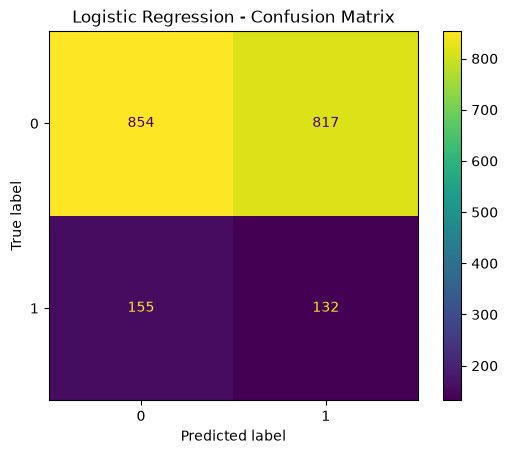

In [80]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Random Forest

In [81]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=6,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [82]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['age','gender','country',...,'review_count','avg_user_rating', 'avg_sentiment']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [83]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [84]:
evaluate_model(
    "Random Forest",
    y_test,
    y_pred,
    y_prob
)

Random Forest
Accuracy: 0.6470888661899897
Precision: 0.1576271186440678
Recall: 0.3240418118466899
F1: 0.2120866590649943
ROC-AUC: 0.5142385894235962

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.70      0.77      1671
           1       0.16      0.32      0.21       287

    accuracy                           0.65      1958
   macro avg       0.51      0.51      0.49      1958
weighted avg       0.76      0.65      0.69      1958



The predicitions with low ROC-AUC score prove that this dataset has similar distribution to users churned and no churned, so not even XGBoost can have a good test accuracy.

### XGBoost